In [2]:
import glob
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import time
from scipy import sparse
import anndata
import seaborn as sns
import scvelo as scv

In [3]:
import sys
sys.path.append("../src/")
import MoFlow as mf

In [4]:
import matplotlib
matplotlib.rcParams.update({'font.size': 12})
matplotlib.rcParams.update({'figure.facecolor': 'white'})
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
matplotlib.rcParams['svg.fonttype'] = 'none'

matplotlib.rcParams['ytick.labelright'] = False
matplotlib.rcParams['ytick.labelleft'] = True
matplotlib.rcParams['ytick.right'] = False
matplotlib.rcParams['ytick.left'] = True

In [9]:
multivelo = anndata.read_h5ad(
    '../data/Human_brain/adata_multivelo.h5ad')
adata_out = anndata.read_h5ad(
    '../data/Human_brain/adata_moflow.h5ad')

In [6]:
from scipy import stats

In [11]:
threshold =  np.linspace(0, 95, 20)[::-1]

In [13]:
model_dfs_hb = []
for w in np.linspace(0, 95, 20)[::-1]:
    model_df = mf.eval.get_genescore(adata_out,
                                    w_threshold=w, scorenorm=False)
    genelist = set(adata_out.var_names) & set(multivelo.var_names)
    adata_out_ = adata_out[:, adata_out.var_names.isin(genelist)]
    multivelo_ = multivelo[:, multivelo.var_names.isin(genelist)]

    model_df_ = model_df.loc[ multivelo_.var_names.values]
    model_df_['fit_model'] = multivelo_.var['fit_model']
    model_df_['fit_direction'] = multivelo_.var['fit_direction']
    model_dfs_hb.append(model_df_)


In [33]:
pval_m1_rel = []
pval_m2_rel = []
pval_m1_ind = []
pval_m2_ind = []

for model_df in model_dfs_hb:
    model_df = model_df.copy()
    
    scoresum = model_df['m1']+model_df['m2']
    model_df['m1'] = model_df['m1']/scoresum
    model_df['m2'] = model_df['m2']/scoresum
    
    
    _, pval1 = stats.ttest_rel(model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==1)]['m1'], 
                               model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==1)]['m2'],
                    alternative='greater')
    pval_m1_rel.append(pval1)
    
    _, pval1 = stats.ttest_ind(model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==1)]['m1'], 
                               model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==2)]['m1'], 
                    equal_var=True, alternative='greater')
    pval_m1_ind.append(pval1)

    
    _, pval2 = stats.ttest_rel(model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==2)]['m1'], 
                               model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==2)]['m2'],
                    alternative='less')
    pval_m2_rel.append(pval2)
    
    _, pval2 = stats.ttest_ind(model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==1)]['m2'], 
                               model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==2)]['m2'],
                    equal_var=True, alternative='less')
    pval_m2_ind.append(pval2)


pval_df_hb = pd.DataFrame({
    'pval_m1_ind': pval_m1_ind,
    'pval_m2_ind': pval_m2_ind,
    'pval_m1_rel': pval_m1_rel,
    'pval_m2_rel': pval_m2_rel,},
             index=np.linspace(0, 95, 20)[::-1])

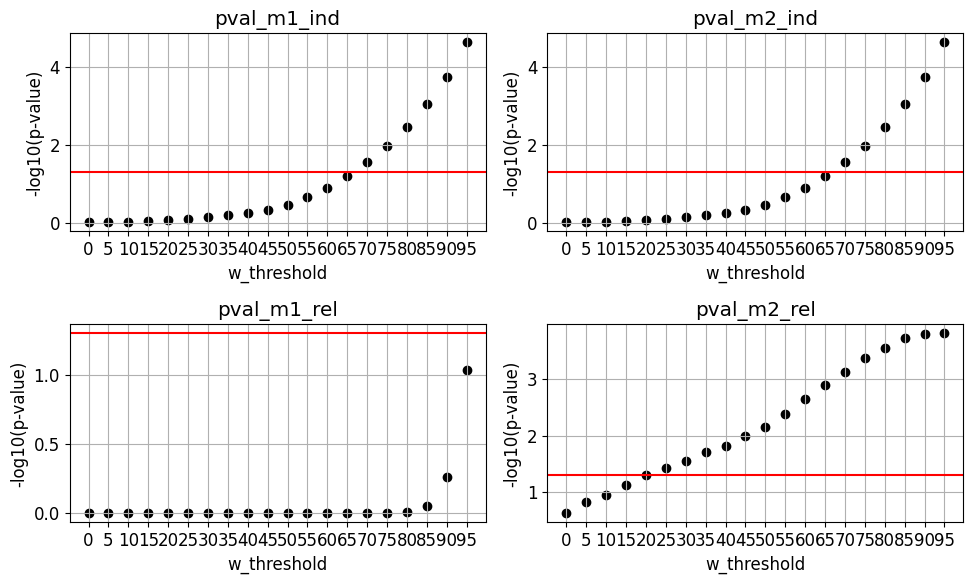

In [34]:
fig, axes = plt.subplots(2,2, figsize=(10,6))
axes = axes.flatten()
pval_df = pval_df_hb.copy()
for _, col in enumerate(pval_df.columns):
    ax = axes[_]
    ax.scatter(x=pval_df.index, y=-np.log10(pval_df[col]), color='black')
    ax.axhline(-np.log10(0.05), color='red')
    ax.set_xlabel('w_threshold')
    ax.set_ylabel(f'-log10(p-value)')
    ax.set_title(col)
    ax.set_xticks([int(t) for t in pval_df.index])
    ax.grid()
fig.tight_layout()

In [20]:
multivelo = anndata.read_h5ad(
    '../data/Mouse_skin/adata_multivelo.h5ad')
adata_out = anndata.read_h5ad(
    '../data/Mouse_skin/adata_moflow.h5ad')

In [22]:
model_dfs_ms = []
for w in np.linspace(0, 95, 20)[::-1]:
    model_df = mf.eval.get_genescore(adata_out,
                                    w_threshold=w, scorenorm=False)
    genelist = set(adata_out.var_names) & set(multivelo.var_names)
    adata_out_ = adata_out[:, adata_out.var_names.isin(genelist)]
    multivelo_ = multivelo[:, multivelo.var_names.isin(genelist)]

    model_df_ = model_df.loc[ multivelo_.var_names.values]
    model_df_['fit_model'] = multivelo_.var['fit_model']
    model_df_['fit_direction'] = multivelo_.var['fit_direction']
    model_dfs_ms.append(model_df_)

In [63]:
pval_m1_rel = []
pval_m2_rel = []
pval_m1_ind = []
pval_m2_ind = []

for model_df in model_dfs_ms:
    model_df = model_df.copy()
    
    scoresum = model_df['m1']+model_df['m2']
    model_df['m1'] = model_df['m1']/scoresum
    model_df['m2'] = model_df['m2']/scoresum
    
    
    _, pval1 = stats.ttest_rel(model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==1)]['m1'], 
                               model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==1)]['m2'],
                    alternative='greater')
    pval_m1_rel.append(pval1)
    
    _, pval1 = stats.ttest_ind(model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==1)]['m1'], 
                               model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==2)]['m1'], 
                    equal_var=True, alternative='greater')
    pval_m1_ind.append(pval1)

    
    _, pval2 = stats.ttest_rel(model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==2)]['m1'], 
                               model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==2)]['m2'],
                    alternative='less')
    pval_m2_rel.append(pval2)
    
    _, pval2 = stats.ttest_ind(model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==1)]['m2'], 
                               model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==2)]['m2'],
                    equal_var=True, alternative='less')
    pval_m2_ind.append(pval2)


pval_df_ms = pd.DataFrame({
    'pval_m1_ind': pval_m1_ind,
    'pval_m2_ind': pval_m2_ind,
    'pval_m1_rel': pval_m1_rel,
    'pval_m2_rel': pval_m2_rel,},
             index=np.linspace(0, 95, 20)[::-1])

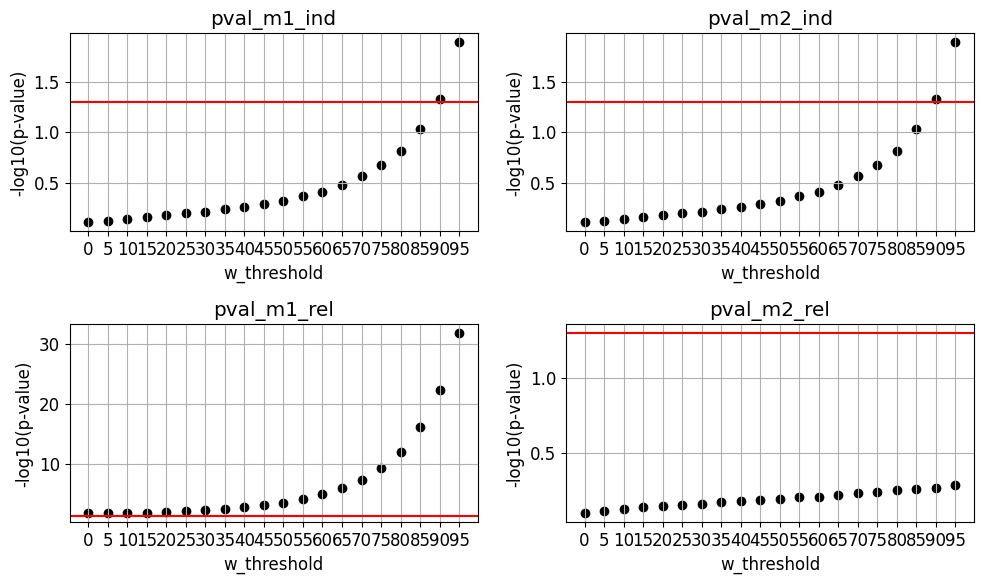

In [64]:
fig, axes = plt.subplots(2,2, figsize=(10,6))
axes = axes.flatten()
pval_df = pval_df_ms.copy()
for _, col in enumerate(pval_df.columns):
    ax = axes[_]
    ax.scatter(x=pval_df.index, y=-np.log10(pval_df[col]), color='black')
    ax.axhline(-np.log10(0.05), color='red')
    ax.set_xlabel('w_threshold')
    ax.set_ylabel(f'-log10(p-value)')
    ax.set_title(col)
    ax.set_xticks([int(t) for t in pval_df.index])
    ax.grid()
fig.tight_layout()

In [54]:
multivelo = anndata.read_h5ad(
    '../data/Mouse_brain/adata_multivelo.h5ad')
adata_out = anndata.read_h5ad(
    '../data/Mouse_brain/adata_moflow.h5ad')

In [26]:
model_dfs_mb = []
for w in np.linspace(0, 95, 20)[::-1]:
    model_df = mf.eval.get_genescore(adata_out,
                                    w_threshold=w, scorenorm=False)
    genelist = set(adata_out.var_names) & set(multivelo.var_names)
    adata_out_ = adata_out[:, adata_out.var_names.isin(genelist)]
    multivelo_ = multivelo[:, multivelo.var_names.isin(genelist)]

    model_df_ = model_df.loc[ multivelo_.var_names.values]
    model_df_['fit_model'] = multivelo_.var['fit_model']
    model_df_['fit_direction'] = multivelo_.var['fit_direction']
    model_dfs_mb.append(model_df_)

In [61]:
pval_m1_rel = []
pval_m2_rel = []
pval_m1_ind = []
pval_m2_ind = []

for model_df in model_dfs_mb:
    model_df = model_df.copy()
    
    scoresum = model_df['m1']+model_df['m2']
    model_df['m1'] = model_df['m1']/scoresum
    model_df['m2'] = model_df['m2']/scoresum
    
    
    _, pval1 = stats.ttest_rel(model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==1)]['m1'], 
                               model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==1)]['m2'],
                    alternative='greater')
    pval_m1_rel.append(pval1)
    
    _, pval1 = stats.ttest_ind(model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==1)]['m1'], 
                               model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==2)]['m1'], 
                    equal_var=True, alternative='greater')
    pval_m1_ind.append(pval1)

    
    _, pval2 = stats.ttest_rel(model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==2)]['m1'], 
                               model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==2)]['m2'],
                    alternative='less')
    pval_m2_rel.append(pval2)
    
    _, pval2 = stats.ttest_ind(model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==1)]['m2'], 
                               model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==2)]['m2'],
                    equal_var=True, alternative='less')
    pval_m2_ind.append(pval2)


pval_df_mb = pd.DataFrame({
    'pval_m1_ind': pval_m1_ind,
    'pval_m2_ind': pval_m2_ind,
    'pval_m1_rel': pval_m1_rel,
    'pval_m2_rel': pval_m2_rel,},
             index=np.linspace(0, 95, 20)[::-1])

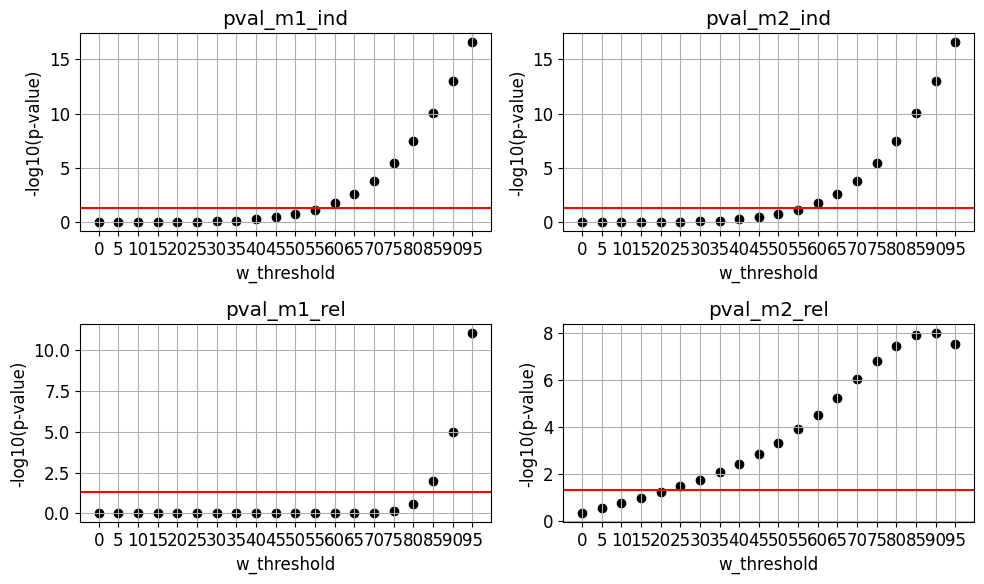

In [40]:
fig, axes = plt.subplots(2,2, figsize=(10,6))
axes = axes.flatten()
pval_df = pval_df_mb.copy()
for _, col in enumerate(pval_df.columns):
    ax = axes[_]
    ax.scatter(x=pval_df.index, y=-np.log10(pval_df[col]), color='black')
    ax.axhline(-np.log10(0.05), color='red')
    ax.set_xlabel('w_threshold')
    ax.set_ylabel(f'-log10(p-value)')
    ax.set_title(col)
    ax.set_xticks([int(t) for t in pval_df.index])
    ax.grid()
fig.tight_layout()

In [29]:
multivelo = anndata.read_h5ad(
    '../data/HSPC/adata_multivelo.h5ad')
adata_out = anndata.read_h5ad(
    '../data/HSPC/adata_moflow.h5ad')

In [30]:
model_dfs_hh = []
for w in np.linspace(0, 95, 20)[::-1]:
    model_df = mf.eval.get_genescore(adata_out,
                                    w_threshold=w, scorenorm=False)
    genelist = set(adata_out.var_names) & set(multivelo.var_names)
    adata_out_ = adata_out[:, adata_out.var_names.isin(genelist)]
    multivelo_ = multivelo[:, multivelo.var_names.isin(genelist)]

    model_df_ = model_df.loc[ multivelo_.var_names.values]
    model_df_['fit_model'] = multivelo_.var['fit_model']
    model_df_['fit_direction'] = multivelo_.var['fit_direction']
    model_dfs_hh.append(model_df_)

In [60]:
pval_m1_rel = []
pval_m2_rel = []
pval_m1_ind = []
pval_m2_ind = []

for model_df in model_dfs_hh:
    model_df = model_df.copy()
    
    scoresum = model_df['m1']+model_df['m2']
    model_df['m1'] = model_df['m1']/scoresum
    model_df['m2'] = model_df['m2']/scoresum
    
    
    _, pval1 = stats.ttest_rel(model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==1)]['m1'], 
                               model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==1)]['m2'],
                    alternative='greater')
    pval_m1_rel.append(pval1)
    
    _, pval1 = stats.ttest_ind(model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==1)]['m1'], 
                               model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==2)]['m1'], 
                    equal_var=True, alternative='greater')
    pval_m1_ind.append(pval1)

    
    _, pval2 = stats.ttest_rel(model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==2)]['m1'], 
                               model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==2)]['m2'],
                    alternative='less')
    pval_m2_rel.append(pval2)
    
    _, pval2 = stats.ttest_ind(model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==1)]['m2'], 
                               model_df[(model_df['fit_direction']=='complete')&
                               (model_df['fit_model']==2)]['m2'],
                    equal_var=True, alternative='less')
    pval_m2_ind.append(pval2)


pval_df_hh = pd.DataFrame({
    'pval_m1_ind': pval_m1_ind,
    'pval_m2_ind': pval_m2_ind,
    'pval_m1_rel': pval_m1_rel,
    'pval_m2_rel': pval_m2_rel,},
             index=np.linspace(0, 95, 20)[::-1])

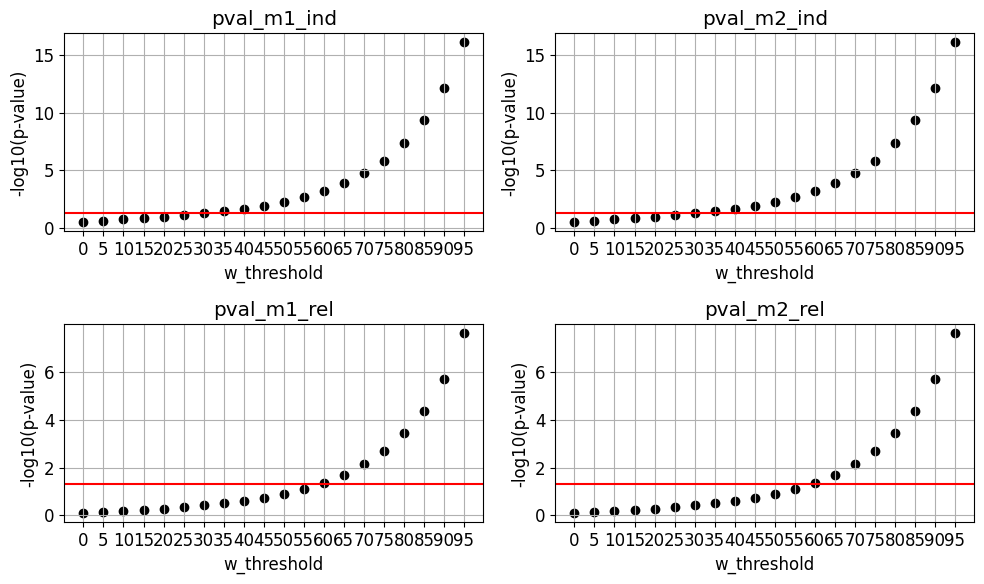

In [44]:
fig, axes = plt.subplots(2,2, figsize=(10,6))
axes = axes.flatten()
pval_df = pval_df_hh.copy()
for _, col in enumerate(pval_df.columns):
    ax = axes[_]
    ax.scatter(x=pval_df.index, y=-np.log10(pval_df[col]), color='black')
    ax.axhline(-np.log10(0.05), color='red')
    ax.set_xlabel('w_threshold')
    ax.set_ylabel(f'-log10(p-value)')
    ax.set_title(col)
    ax.set_xticks([int(t) for t in pval_df.index])
    ax.grid()
fig.tight_layout()

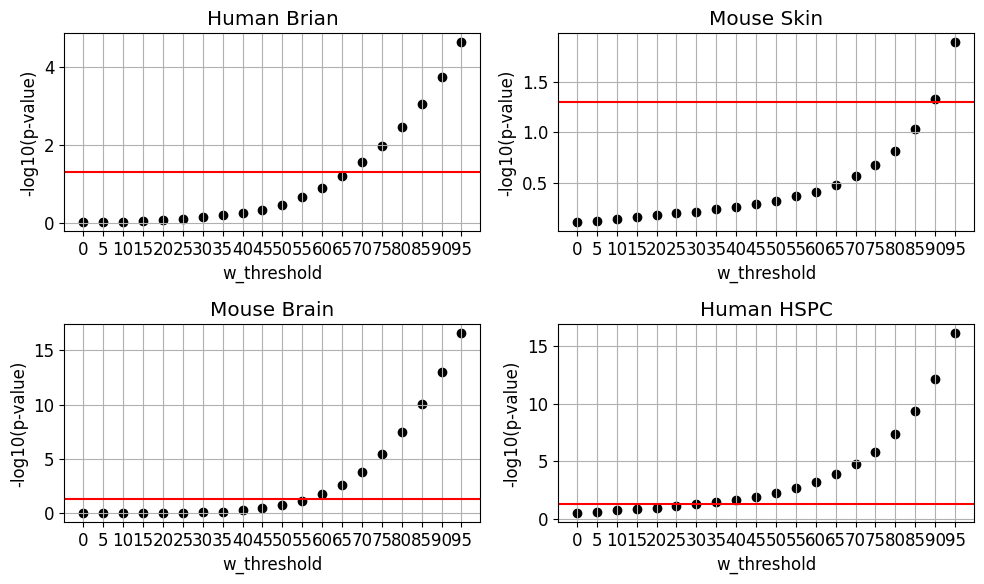

In [79]:
fig, axes = plt.subplots(2,2, figsize=(10,6))
axes = axes.flatten()
names = ['Human Brian', 'Mouse Skin', 'Mouse Brain', 'Human HSPC']
for i, pval_df in enumerate([pval_df_hb, pval_df_ms, pval_df_mb, pval_df_hh]):
    ax=axes[i]
    ax.scatter(x=pval_df.index, 
               y=-np.log10(pval_df['pval_m1_ind']),
               color='black')
    ax.set_title(names[i])
    
axes = axes.flatten()
for ax in axes:
    ax.axhline(-np.log10(0.05), color='red')
    ax.set_xlabel('w_threshold')
    ax.set_ylabel(f'-log10(p-value)')
    ax.set_xticks([int(t) for t in pval_df.index])
    ax.grid()
fig.tight_layout()
        
    

In [68]:
pval_df

,pval_m1_ind,pval_m2_ind,pval_m1_rel,pval_m2_rel
95.0,0.012935,0.012935,1.712445e-32,0.520500
90.0,0.046544,0.046544,5.118665e-23,0.543077
85.0,0.093047,0.093047,8.235364e-17,0.550067
80.0,0.153663,0.153663,9.744661e-13,0.565895
75.0,0.211506,0.211506,5.566317e-10,0.576373
70.0,0.271844,0.271844,4.220845e-08,0.591534
65.0,0.332745,0.332745,1.063025e-06,0.608486
60.0,0.386156,0.386156,1.200857e-05,0.621805
55.0,0.428542,0.428542,7.362290e-05,0.630971
50.0,0.470361,0.470361,2.980600e-04,0.642042
